In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcZ2FicmlcT25lRHJpdmVccHl0aG9uLmdpdGh1Yi5pbw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

C:\Users\gabri\AppData\Local\Temp\ipykernel_14488\3437675630.py:25: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


{"C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\importlib\\_bootstrap.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\importlib\\_bootstrap_external.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\codecs.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\aliases.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\__init__.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\utf_8.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\cp1252.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\abc.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\io.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\li

In [2]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler

In [3]:
#trocar essa url pelo caminho da base Stroke Prediction Dataset de vocês.
stroke = pd.read_csv("Cadernos Grupo Python\\Pré-Processamento\\healthcare-dataset-stroke-data.csv")
print(stroke)

         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36.6  former

In [4]:
# Identificar as colunas com variável categórica (variáveis categóricas podem aparecer como object)
colunasCategoricas = list(stroke.select_dtypes(include=['object', 'category']).columns)

# Salvando possíveis classes de todas as variáveis categóricas
classesColCateg = []
for coluna in colunasCategoricas:
    #Exibindo as diferentes classes presentes em uma coluna com variável categórica
    print(f"{coluna}: {list(stroke[coluna].unique())}")
    classesColCateg.append(list(stroke[coluna].unique()))

gender: ['Male', 'Female', 'Other']
ever_married: ['Yes', 'No']
work_type: ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Residence_type: ['Urban', 'Rural']
smoking_status: ['formerly smoked', 'never smoked', 'smokes', 'Unknown']


In [5]:
x_strokeKfold, x_strokeValidacao, y_strokeKfold, y_strokeValidacao = train_test_split(stroke.drop(columns=['stroke']), stroke['stroke'], test_size=0.1, random_state=11)

In [6]:
def testeMetricasKFold(XBase, YBase, n_splits, random_state, funcaoAlgoritmo):
    """Função para testar acurácia, sensibilidade e especificidade de uma dada base passando por reamostragem por k-fold usando o algoritmo inserido"""
    # criação de uma lista para reutilização do generator 
    kfBase = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state).split(XBase, YBase)
    kfBaseLista = list(kfBase)
  
    # Salvando apenas os índices dos folds em listas [[[treino], [teste]], [[treino], [teste]], ...]  
    foldsBase = []
    for K, (train, test) in enumerate(kfBaseLista, 1):
        # Não guarda K porque não precisa, é o índice da lista mais 1.
        foldsBase.append([list(train), list(test)])
        #print("K:", K, "train:", len(train), "test:", len(test))
  
    # Criando os modelos individuais de cada fold
    modelosIndividuais = []
    for fold in foldsBase:
        modelosIndividuais.append(funcaoAlgoritmo(random_state=random_state).fit(XBase.iloc[fold[0]], YBase.iloc[fold[0]]))

    # Testando os modelos individuais de cada fold
    acuraciaModelos = []
    sensibilidadeModelos = []
    especificidadeModelos = []
    for i in range(len(modelosIndividuais)):
        Y_predBase = modelosIndividuais[i].predict(XBase.iloc[foldsBase[i][1]])
        vn, fp, fn, vp = confusion_matrix(YBase.iloc[foldsBase[i][1]], Y_predBase).ravel()
        acuracia = (vp + vn) / (vp + vn + fp + fn)
        sensibilidade = vp / (vp + fn)
        especificidade = vn / (vn + fp)
        acuraciaModelos.append(acuracia)
        sensibilidadeModelos.append(sensibilidade)
        especificidadeModelos.append(especificidade)
  
    # Printando o compilado de métricas
    print(f"Média da acurácia: {(sum(acuraciaModelos)/len(acuraciaModelos)*100):.1f}%")
    print(f"Desvio padrão populacional da acurácia: {np.std(acuraciaModelos, ddof=0):.3f}\n")
    print(f"Média da sensibilidade: {(sum(sensibilidadeModelos)/len(sensibilidadeModelos)*100):.1f}%")
    print(f"Desvio padrão populacional da sensibilidade: {np.std(sensibilidadeModelos, ddof=0):.3f}\n")
    print(f"Média da especificidade: {(sum(especificidadeModelos)/len(especificidadeModelos)*100):.1f}%")
    print(f"Desvio padrão populacional da especificidade: {np.std(especificidadeModelos, ddof=0):.3f}\n")

In [7]:
x_strokeKfold = x_strokeKfold.drop('id', axis=1)

In [8]:
print(x_strokeKfold["smoking_status"].value_counts())

smoking_status
never smoked       1687
Unknown            1383
formerly smoked     795
smokes              734
Name: count, dtype: int64


In [9]:
print(x_strokeKfold["gender"].value_counts())

gender
Female    2689
Male      1909
Other        1
Name: count, dtype: int64


In [10]:
x_strokeKfold = x_strokeKfold.replace({
    "gender": {"Other": pd.NA},          
    "smoking_status": {"Unknown": pd.NA} 
})

In [11]:
print(x_strokeKfold.isna().sum())

gender                  1
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   184
smoking_status       1383
dtype: int64


In [12]:
for i in range(len(classesColCateg)):
	  try:
		    classesColCateg[i].remove("Other")
	  except:
		    pass
	  try:
		    classesColCateg[i].remove("Unknown")
	  except:
		    pass

In [13]:
# Como estamos removendo uma linha do dataframe das variáveis explicativas, precisamos fazer o mesmo com a variável resposta, depois de tudo precisamos resetar os índices.
indices_eliminados = x_strokeKfold[x_strokeKfold["gender"].isna()].index
x_strokeKfold = x_strokeKfold.dropna(subset=["gender"])
y_strokeKfold = y_strokeKfold.drop(indices_eliminados)

x_strokeKfold = x_strokeKfold.reset_index(drop=True)
y_strokeKfold = y_strokeKfold.reset_index(drop=True)

# Como retiramos a única amostra Other de gender, precisamos tirar "Other" da lista de categorias de gender.
# para não ser um problema na codificação de variáveis.
# Não precisa fazer se já feito anteriormente.
try:
	  classesColCateg[colunasCategoricas.index("gender")].remove("Other")
except:
	  pass

In [14]:
print(x_strokeKfold['bmi'].median())
print(x_strokeKfold['smoking_status'].mode())

28.1
0    never smoked
Name: smoking_status, dtype: object


In [15]:
x_strokeKfold = x_strokeKfold.replace({       
    "smoking_status": {pd.NA: "never smoked"} #,
    #"bmi": {pd.NA: 28.1} 
})

In [16]:
# Comentado para usar depois das transformações e codificações de variáveis
#x_strokeKfold['bmi'] = KNNImputer(n_neighbors=10).fit_transform(x_strokeKfold)[:, x_strokeKfold.columns.get_loc('bmi')]

In [17]:
print(colunasCategoricas)
print(classesColCateg)

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
[['Male', 'Female'], ['Yes', 'No'], ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'], ['Urban', 'Rural'], ['formerly smoked', 'never smoked', 'smokes']]


In [18]:
colunasCategoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
classesColCateg = [['Male', 'Female'], ['Yes', 'No'], ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'], ['Urban', 'Rural'], ['formerly smoked', 'never smoked', 'smokes', 'Unknown']]

In [19]:
# Para cada coluna
for i in range(len(colunasCategoricas)):
	  # Para cada classe de cada coluna
	  for j in range(len(classesColCateg[i])):
		    #Se for Dummy Variables descomente o seguinte if e continue:
		    #if j == 0:
			      #continue
		    x_strokeKfold[colunasCategoricas[i]+"_"+classesColCateg[i][j]] = (x_strokeKfold[colunasCategoricas[i]] == classesColCateg[i][j]).astype(int)
		    print(x_strokeKfold[colunasCategoricas[i]+"_"+classesColCateg[i][j]])

0       1
1       1
2       0
3       1
4       0
       ..
4593    1
4594    1
4595    0
4596    0
4597    1
Name: gender_Male, Length: 4598, dtype: int64
0       0
1       0
2       1
3       0
4       1
       ..
4593    0
4594    0
4595    1
4596    1
4597    0
Name: gender_Female, Length: 4598, dtype: int64
0       1
1       1
2       1
3       1
4       0
       ..
4593    1
4594    1
4595    1
4596    1
4597    1
Name: ever_married_Yes, Length: 4598, dtype: int64
0       0
1       0
2       0
3       0
4       1
       ..
4593    0
4594    0
4595    0
4596    0
4597    0
Name: ever_married_No, Length: 4598, dtype: int64


0       1
1       0
2       0
3       0
4       1
       ..
4593    0
4594    1
4595    1
4596    1
4597    1
Name: work_type_Private, Length: 4598, dtype: int64
0       0
1       1
2       1
3       0
4       0
       ..
4593    1
4594    0
4595    0
4596    0
4597    0
Name: work_type_Self-employed, Length: 4598, dtype: int64
0       0
1       0
2       0
3       1
4       0
       ..
4593    0
4594    0
4595    0
4596    0
4597    0
Name: work_type_Govt_job, Length: 4598, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4593    0
4594    0
4595    0
4596    0
4597    0
Name: work_type_children, Length: 4598, dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
4593    0
4594    0
4595    0
4596    0
4597    0
Name: work_type_Never_worked, Length: 4598, dtype: int64
0       1
1       1
2       1
3       1
4       0
       ..
4593    1
4594    0
4595    1
4596    1
4597    1
Name: Residence_type_Urban, Length: 4598, dtype: int64
0       0
1 

In [20]:
for coluna in colunasCategoricas:
    x_strokeKfold = x_strokeKfold.drop(coluna, axis=1)

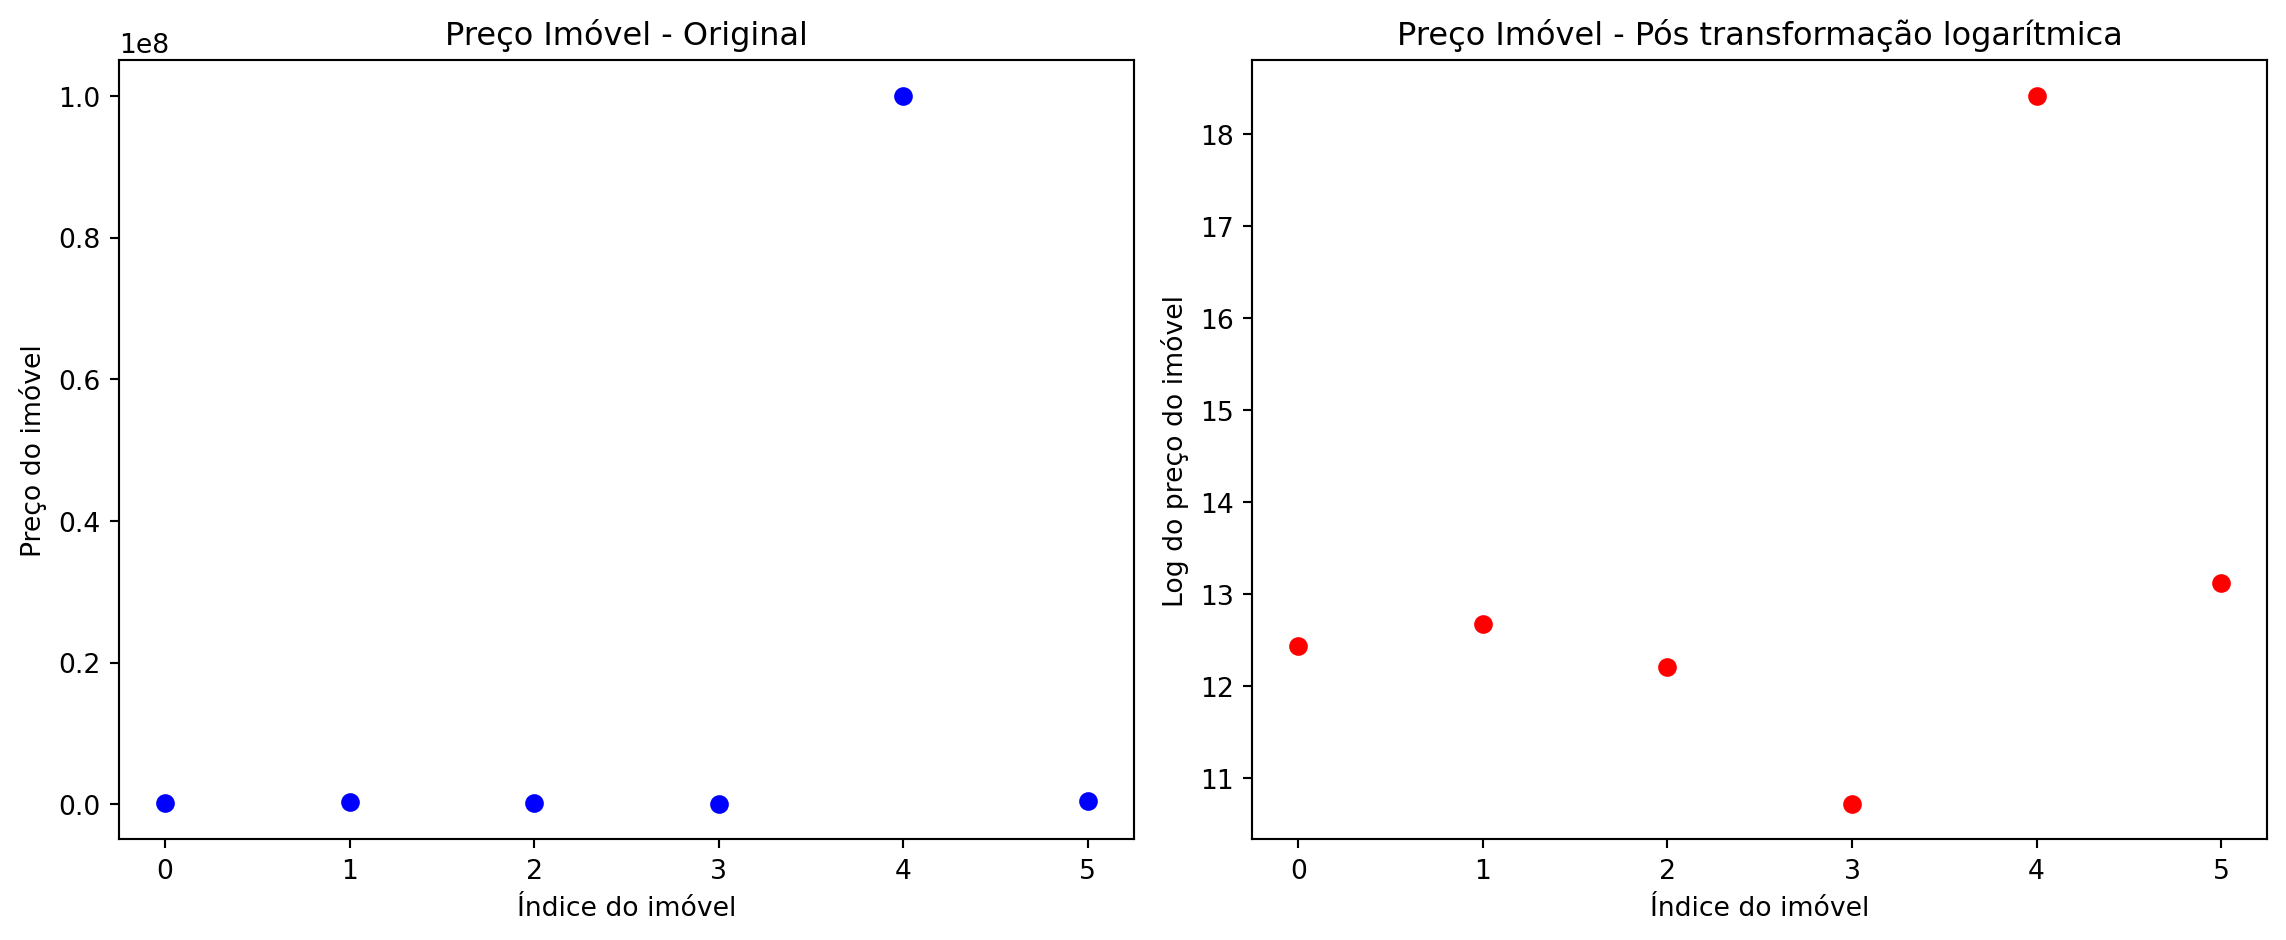

In [21]:
# Dados
precoImoveis = [250000, 320000, 200000, 45000, 100000000, 500000]
tipoImoveis = ['apartamento', 'casa', 'casa', 'apartamento', 'palacio', 'casa']
dadosImoveis = pd.DataFrame({'tipoImovel': tipoImoveis, 'precoImovel': precoImoveis})

# Transformação logarítmica
dadosImoveis['precoImovel_log'] = np.log(dadosImoveis['precoImovel'])

# Scatter plot
plt.figure(figsize=(12,5))

# Scatter original
plt.subplot(1,2,1)
plt.scatter(dadosImoveis.index, dadosImoveis['precoImovel'], color='blue')
plt.title('Preço Imóvel - Original')
plt.xlabel('Índice do imóvel')
plt.ylabel('Preço do imóvel')

# Scatter logarítmico
plt.subplot(1,2,2)
plt.scatter(dadosImoveis.index, dadosImoveis['precoImovel_log'], color='red')
plt.title('Preço Imóvel - Pós transformação logarítmica')
plt.xlabel('Índice do imóvel')
plt.ylabel('Log do preço do imóvel')

plt.tight_layout()
plt.show()

In [22]:
# Definição  dos mínimos e máximos a serem utilizados
print("Mínimo age:", x_strokeKfold['age'].min())
print("Máximo age:", x_strokeKfold['age'].max())
print("Mínimo avg_glucose_level:", x_strokeKfold['avg_glucose_level'].min())
print("Máximo avg_glucose_level:", x_strokeKfold['avg_glucose_level'].max())
print("Mínimo bmi:", x_strokeKfold['bmi'].min())
print("Máximo bmi:", x_strokeKfold['bmi'].max())

Mínimo age: 0.08
Máximo age: 82.0
Mínimo avg_glucose_level: 55.12
Máximo avg_glucose_level: 271.74
Mínimo bmi: 10.3
Máximo bmi: 97.6


In [23]:
x_strokeKfold['age'] = (x_strokeKfold['age'] - 0.08)/(82.0-0.08)
x_strokeKfold['avg_glucose_level'] = (x_strokeKfold['avg_glucose_level'] - 55.12)/(271.74-55.12)
x_strokeKfold['bmi'] = (x_strokeKfold['bmi'] - 10.3)/(97.6-10.3)

In [24]:
print("Desvio padrão populacional de age:", np.std(x_strokeKfold['age']))
print("Média de age:", np.mean(x_strokeKfold['age']))
print("Desvio padrão populacional de avg_glucose_level:", np.std(x_strokeKfold['avg_glucose_level']))
print("Média de avg_glucose_level:", np.mean(x_strokeKfold['avg_glucose_level']))
print("Desvio padrão populacional de bmi:", np.std(x_strokeKfold['bmi']))
print("Média de age:", np.mean(x_strokeKfold['bmi']))

Desvio padrão populacional de age: 0.2745076710096592
Média de age: 0.5288690182892019
Desvio padrão populacional de avg_glucose_level: 0.20818373232293189
Média de avg_glucose_level: 0.23528482535810868
Desvio padrão populacional de bmi: 0.08981209816205521
Média de age: 0.21331922639150344


In [25]:
#x_strokeKfold['age'] = (x_strokeKfold['age'] - 43.4)/(22.49)
#x_strokeKfold['avg_glucose_level'] = (x_strokeKfold['avg_glucose_level'] - 106.1)/(45.1)
#x_strokeKfold['bmi'] = (x_strokeKfold['bmi'] - 28.9)/(7.8)

In [26]:
x_strokeKfold['bmi'] = KNNImputer(n_neighbors=10).fit_transform(x_strokeKfold)[:, x_strokeKfold.columns.get_loc('bmi')]

In [27]:
pd.set_option("display.max_columns", None)
print(x_strokeKfold)

           age  hypertension  heart_disease  avg_glucose_level       bmi  \
0     0.755859             0              0           0.080233  0.139748   
1     0.572754             0              0           0.369633  0.294387   
2     0.877930             0              1           0.403979  0.258877   
3     0.682617             0              0           0.310544  0.229095   
4     0.169922             0              0           0.131290  0.261168   
...        ...           ...            ...                ...       ...   
4593  0.401855             0              0           0.806943  0.178694   
4594  0.560547             1              0           0.085865  0.221191   
4595  0.462891             0              0           0.223710  0.234822   
4596  0.768066             0              0           0.132121  0.127148   
4597  0.401855             0              0           0.201366  0.390607   

      gender_Male  gender_Female  ever_married_Yes  ever_married_No  \
0               

In [28]:
print(y_strokeKfold.value_counts())

stroke
0    4375
1     223
Name: count, dtype: int64


In [29]:
# Base balanceada

# criando a base balanceada
x_strokeKfoldBalanceado, y_strokeKfoldBalanceado = RandomUnderSampler(sampling_strategy=0.5/0.5, random_state=11).fit_resample(x_strokeKfold, y_strokeKfold)

# print do estado de balanceamento atual
print(y_strokeKfoldBalanceado.value_counts())

stroke
0    223
1    223
Name: count, dtype: int64


In [30]:
# Base enviesada para AVC

# definindo o número de amostras para sampling_strategy
nAmostrasMinoritaria = y_strokeKfold.value_counts()[1]

# criando a base enviesada para AVC
x_strokeKfoldEnviesadoAVC, y_strokeKfoldEnviesadoAVC = RandomUnderSampler(sampling_strategy={0: int(nAmostrasMinoritaria*0.67), 1: nAmostrasMinoritaria}, random_state=11).fit_resample(x_strokeKfold, y_strokeKfold)

# print do estado de balanceamento atual
print(y_strokeKfoldEnviesadoAVC.value_counts())

stroke
1    223
0    149
Name: count, dtype: int64


In [31]:
# Base enviesada para sem AVC

# criando a base enviesada para sem AVC
x_strokeKfoldEnviesadoSemAVC, y_strokeKfoldEnviesadoSemAVC = RandomUnderSampler(sampling_strategy=0.4/0.6, random_state=11).fit_resample(x_strokeKfold, y_strokeKfold)

# print do estado de balanceamento atual
print(y_strokeKfoldEnviesadoSemAVC.value_counts())

stroke
0    334
1    223
Name: count, dtype: int64


In [32]:
#Relembrando o cabeçalho da função:
#testeMetricasKFold(XBase, YBase, n_splits, random_state, funcaoAlgoritmo)
print("Resultados base balanceada:")
testeMetricasKFold(x_strokeKfoldBalanceado, y_strokeKfoldBalanceado, n_splits=10, random_state=11, funcaoAlgoritmo=RandomForestClassifier)

print("\n\nResultados base enviesada para AVC:")
testeMetricasKFold(x_strokeKfoldEnviesadoAVC, y_strokeKfoldEnviesadoAVC, n_splits=10, random_state=11, funcaoAlgoritmo=RandomForestClassifier)

print("\n\nResultados base enviesada para sem AVC:")
testeMetricasKFold(x_strokeKfoldEnviesadoSemAVC, y_strokeKfoldEnviesadoSemAVC, n_splits=10, random_state=11, funcaoAlgoritmo=RandomForestClassifier)

Resultados base balanceada:


Média da acurácia: 74.5%
Desvio padrão populacional da acurácia: 0.071

Média da sensibilidade: 78.5%
Desvio padrão populacional da sensibilidade: 0.055

Média da especificidade: 70.4%
Desvio padrão populacional da especificidade: 0.099



Resultados base enviesada para AVC:


Média da acurácia: 79.3%
Desvio padrão populacional da acurácia: 0.072

Média da sensibilidade: 87.5%
Desvio padrão populacional da sensibilidade: 0.072

Média da especificidade: 67.0%
Desvio padrão populacional da especificidade: 0.119



Resultados base enviesada para sem AVC:


Média da acurácia: 76.7%
Desvio padrão populacional da acurácia: 0.041

Média da sensibilidade: 72.6%
Desvio padrão populacional da sensibilidade: 0.068

Média da especificidade: 79.4%
Desvio padrão populacional da especificidade: 0.055



In [33]:
# Tratamento de NAs
x_strokeValidacao = x_strokeValidacao.drop('id', axis=1)
x_strokeValidacao = x_strokeValidacao.replace({
    "gender": {"Other": 'Male'},          
    "smoking_status": {"Unknown": 'never smoked'},
    "bmi": {pd.NA: 28.1} 
})

# One-Hot encoding (Codificação de variáveis)
colunasCategoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
classesColCateg = [['Male', 'Female'], ['Yes', 'No'], ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'], ['Urban', 'Rural'], ['formerly smoked', 'never smoked', 'smokes', 'Unknown']]
# Para cada coluna
for i in range(len(colunasCategoricas)):
	  # Para cada classe de cada coluna
	  for j in range(len(classesColCateg[i])):
		    #Se for Dummy Variables descomente o seguinte if e continue:
		    #if j == 0:
			      #continue
		    x_strokeValidacao[colunasCategoricas[i]+"_"+classesColCateg[i][j]] = (x_strokeValidacao[colunasCategoricas[i]] == classesColCateg[i][j]).astype(int)
for coluna in colunasCategoricas:
    x_strokeValidacao = x_strokeValidacao.drop(coluna, axis=1)

# Normalização (Transformação de variáveis)
x_strokeValidacao['age'] = (x_strokeValidacao['age'] - 0.08)/(82.0-0.08)
x_strokeValidacao['avg_glucose_level'] = (x_strokeValidacao['avg_glucose_level'] - 55.12)/(271.74-55.12)
x_strokeValidacao['bmi'] = (x_strokeValidacao['bmi'] - 10.3)/(97.6-10.3)

In [34]:
model = RandomForestClassifier(random_state=11).fit(x_strokeKfoldEnviesadoAVC, y_strokeKfoldEnviesadoAVC)
predicoes = model.predict(x_strokeValidacao)
vn, fp, fn, vp = confusion_matrix(y_strokeValidacao, predicoes).ravel()
acuracia = (vp + vn) / (vp + vn + fp + fn)
sensibilidade = vp / (vp + fn)
especificidade = vn / (vn + fp)

print("Acurácia:", acuracia)
print("Sensibilidade:", sensibilidade)
print("Especificidade:", especificidade)

Acurácia: 0.6594911937377691
Sensibilidade: 0.9230769230769231
Especificidade: 0.6453608247422681
